## instalando as biliotecas: 
python -m pip install pandas matplotlib seaborn

In [17]:

import pandas as pd

df_balanco = pd.read_csv('balanco_servico_ano.csv', sep=None, engine='python')
df_trajeto = pd.read_csv('ordem_servico_trajeto_alternativo_sentido.csv', sep=None, engine='python')

# criando um dicionário de inspeção: (resumo dos arquivos pra facilitar)

balanco_info = {
    "columns": df_balanco.columns.tolist(), # pega nome das colunas e coloca em uma lista
    "head": df_balanco.head().to_dict() # pega as 5 primeiras linhas e transforma em um dicionário
}

trajeto_info = {

        "columns": df_trajeto.columns.tolist(),
        "head": df_trajeto.head().to_dict()
}

# print pra visualizar

print("Colunas Balanço:", balanco_info['columns'])
print("Colunas Trajeto:", trajeto_info['columns'])


Colunas Balanço: ['ano', 'servico', 'consorcio', 'km_apurada', 'receita_total_esperada', 'receita_tarifaria_esperada', 'subsidio_esperado', 'subsidio_glosado', 'receita_total_aferida', 'receita_tarifaria_aferida', 'subsidio_pago', 'saldo', 'versao', 'datetime_ultima_atualizacao', 'id_execucao_dbt']
Colunas Trajeto: ['feed_version', 'feed_start_date', 'feed_end_date', 'tipo_os', 'servico', 'consorcio', 'sentido', 'vista', 'ativacao', 'evento', 'extensao', 'versao_modelo']


    servico   km_apurada  qtd_trajetos_alternativos  km_alto
75      371  5233980.654                        0.0     True
269     864  5233708.360                        0.0     True
83      388  5226813.408                        0.0     True
89      397  5047798.703                        0.0     True
167     639  4534565.440                        0.0     True
161     629  4313520.271                        0.0     True
46      309  3863023.979                        2.0     True
50      315  3823780.001                        0.0     True
137     565  3782815.689                       54.0     True
133     554  3736920.246                       27.0     True


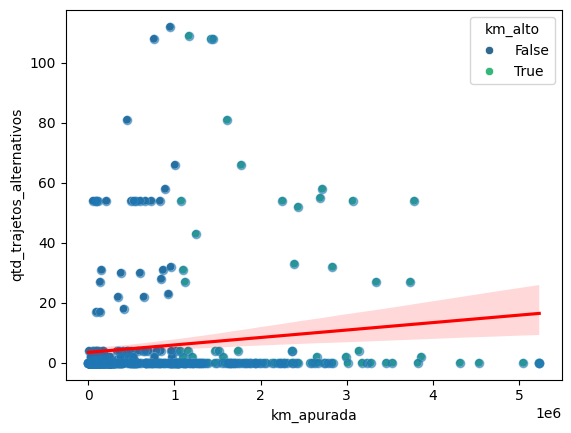

In [18]:
import seaborn as sns
import matplotlib as plt

# transformando os dados nas informações úteis

# resumo da quilometragem
df_balanco_agrupado = df_balanco.groupby('servico')['km_apurada'].sum().reset_index()
## junta as linhas do mesmo serviço de onibus e soma os valores da coluna, tendo o total pra cada linha de onibus

df_trajeto_contagem = df_trajeto.groupby('servico').size().reset_index(name='qtd_trajetos_alternativos')
## conta quantas vezes cada linha de onibus aparece no arquivo com os trajetos alternativos

# cruzando os dados:
df_analise = pd.merge(df_balanco_agrupado, df_trajeto_contagem, on='servico', how='left').fillna(0)
## cola a lista com a quilometragem do lado da lista de contagem de problemas, incluindo as linhas que nao tiveram problemas
## se uma linha nao tiver aparecido no arquivo de problemas, preenche com "0"

# definição do que é o km alto
limite_km_alto = df_analise['km_apurada'].quantile(0.75)
## pyhton separa a lista das linhas e faz um corte na quantidade de km em 75%, então, as que tiverem rodado mais, serão marcadas
## faz coluna com "TRUE" ou "FALSE" pra facilitar na hora de colorir

df_analise['km_alto'] = df_analise['km_apurada'] > limite_km_alto

# calculo da correlçaão e construção do gráfico
correlacao = df_analise['km_apurada'].corr(df_analise['qtd_trajetos_alternativos'])
## utiliza o coeficiente de Pearson: se o resultado for perto de 1, a teoria de +KM = +problema confere.
## se estiver perto de 0, a maior quilometragem não teve influência significativa nos problemas (trajeto alternativo)

# gráfico de pontos
sns.scatterplot(data=df_analise, x='km_apurada', y='qtd_trajetos_alternativos', hue='km_alto', palette='viridis')
sns.regplot(data=df_analise, x='km_apurada', y='qtd_trajetos_alternativos', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
## linha vermelha de tendencia

top_10_problemas = df_analise.sort_values(by='km_apurada', ascending=False).head(10)
## organiza uma tabela com as 10 linhas que mais rodaram
print(top_10_problemas)


## Conclusões:

Com o gráfico scatter plot, é possi´vel definir se há alguma relação de causa e efeito entre a quilometragem e os problemas no trajeto.

Eixo x : quilometragem total apurada. Quanto mais à direito o ponto está, mais a linha deônibus rodou

Eixo y : quantidade de trajetos alternativos. Quanto mais para cima o ponto está, mais desvios de rota a linha de ônibus teve.

O gráfico explicita que a teoria de que +KM = +problemas não é totalmente verdade! Em resumo, muitas das linhas de ônibus que rodam muito são, na verdade, bem estáveis.
